# 01 — Dataset EDA: Amazon Reviews 2023

Exploratory analysis of the preprocessed train/val/test splits.

**Source:** McAuley-Lab/Amazon-Reviews-2023 (Electronics + All_Beauty subsets)  
**Label mapping:** 1-2 stars → NEGATIVE (0), 3 stars → NEUTRAL (1), 4-5 stars → POSITIVE (2)  
**Preprocessing:** `data/preprocess.py`, seed=42


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path('..').resolve()
PROCESSED = REPO_ROOT / 'data' / 'processed'

train = pd.read_csv(PROCESSED / 'train.csv')
val   = pd.read_csv(PROCESSED / 'val.csv')
test  = pd.read_csv(PROCESSED / 'test.csv')

LABEL_NAMES = {0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}

print(f'train: {len(train):,}  val: {len(val):,}  test: {len(test):,}')

train: 45,000  val: 13,306  test: 13,306


## 1. Class Distribution

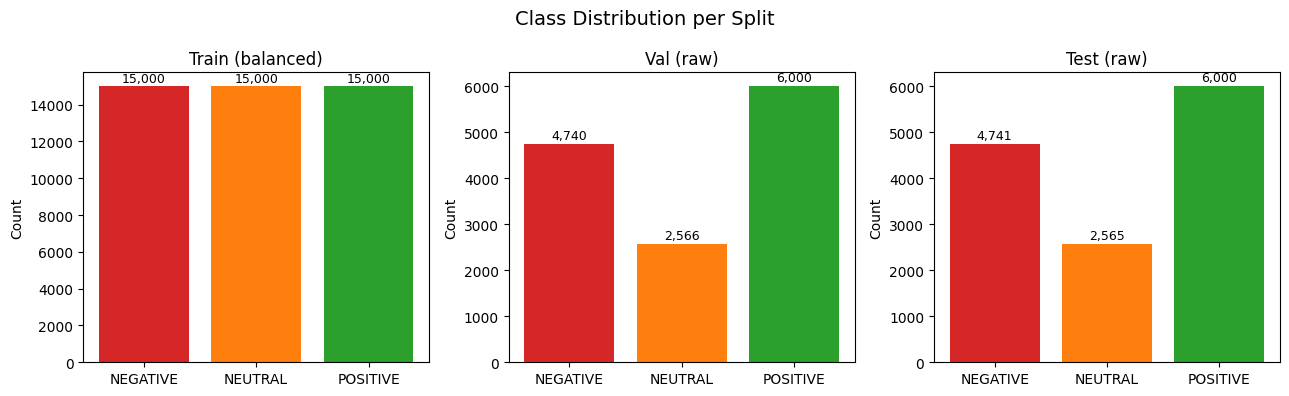

Saved fig01_class_distribution.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Class Distribution per Split', fontsize=14)

for ax, (name, df) in zip(axes, [('Train (balanced)', train), ('Val (raw)', val), ('Test (raw)', test)]):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(
        [LABEL_NAMES[i] for i in counts.index],
        counts.values,
        color=['#d62728', '#ff7f0e', '#2ca02c']
    )
    ax.set_title(name)
    ax.set_ylabel('Count')
    for bar, val_cnt in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                f'{val_cnt:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks' / 'fig01_class_distribution.png', dpi=100)
plt.show()
print('Saved fig01_class_distribution.png')

## 2. Review Length Histograms (characters)

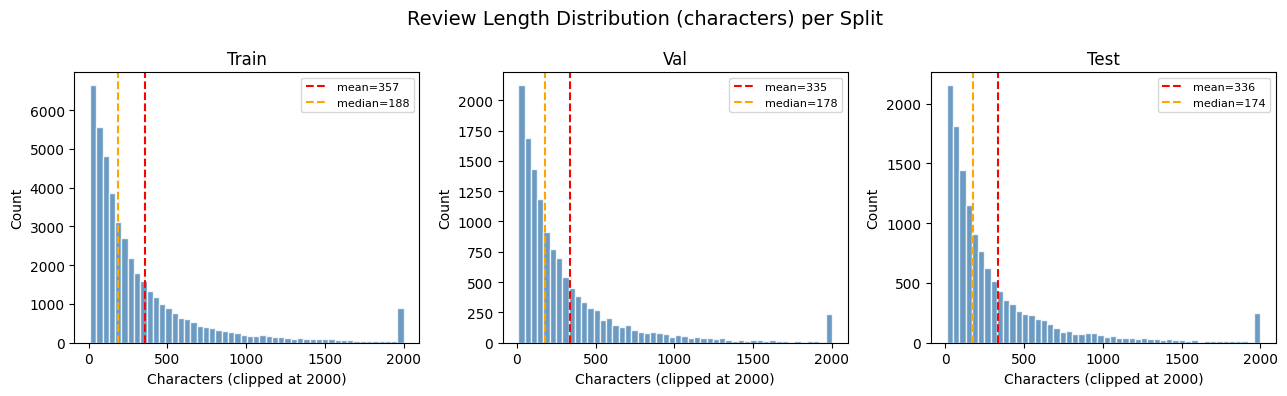

Saved fig02_length_histograms.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Review Length Distribution (characters) per Split', fontsize=14)

for ax, (name, df) in zip(axes, [('Train', train), ('Val', val), ('Test', test)]):
    lengths = df['text'].str.len()
    ax.hist(lengths.clip(upper=2000), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(lengths.mean(), color='red', linestyle='--', label=f'mean={lengths.mean():.0f}')
    ax.axvline(lengths.median(), color='orange', linestyle='--', label=f'median={lengths.median():.0f}')
    ax.set_title(name)
    ax.set_xlabel('Characters (clipped at 2000)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks' / 'fig02_length_histograms.png', dpi=100)
plt.show()
print('Saved fig02_length_histograms.png')

## 3. Length Stats Table

In [4]:
rows = []
for name, df in [('train', train), ('val', val), ('test', test)]:
    lengths = df['text'].str.len()
    rows.append({
        'split': name,
        'mean': round(lengths.mean(), 1),
        'median': round(lengths.median(), 1),
        'p95': round(lengths.quantile(0.95), 1),
        'min': lengths.min(),
        'max': lengths.max(),
    })

pd.DataFrame(rows).set_index('split')

,mean,median,p95,min,max
split,,,,,
train,357.1,188.0,1230.0,10,25552
val,334.9,178.0,1141.0,10,12883
test,336.1,174.0,1166.8,10,12202


## 4. Sample Reviews per Class (Train)

In [5]:
for label_id, label_name in LABEL_NAMES.items():
    print(f'\n=== {label_name} (label={label_id}) ===')
    samples = train[train['label'] == label_id].sample(3, random_state=42)
    for _, row in samples.iterrows():
        print(f'  [{row["rating"]} stars] [{row["category"]}]')
        print(f'  {row["text"][:200]}...' if len(row['text']) > 200 else f'  {row["text"]}')
        print()


=== NEGATIVE (label=0) ===
  [2 stars] [Electronics]
  First of all the mounting holes are too small for standard case screws that hold in the blanks. I had to drill the support holes out to get the standard case screws to go through the mounting holes. T...

  [2 stars] [Beauty]
  Nothing special, I expected a hair free brush.

  [2 stars] [Electronics]
  The quality of the picture is ok. Sound quality is good and picks up everything. The motion detection kind of works but I had to turn off the motion tracking because it left the camera pointing at the...


=== NEUTRAL (label=1) ===
  [3 stars] [Electronics]
  I am coming to this from a full-sized Logitech keyboard. I was looking for something that I could use with my main computer but also to shoot off quick text messages on the iPhone standing in its char...

  [3 stars] [Electronics]
  Does not fit the 22 mustang even without a spare in the well, too tall by at least an inch. If the rtire was in ther eit woudl be double that. Disa

## 5. Class Balance Before vs After Undersampling

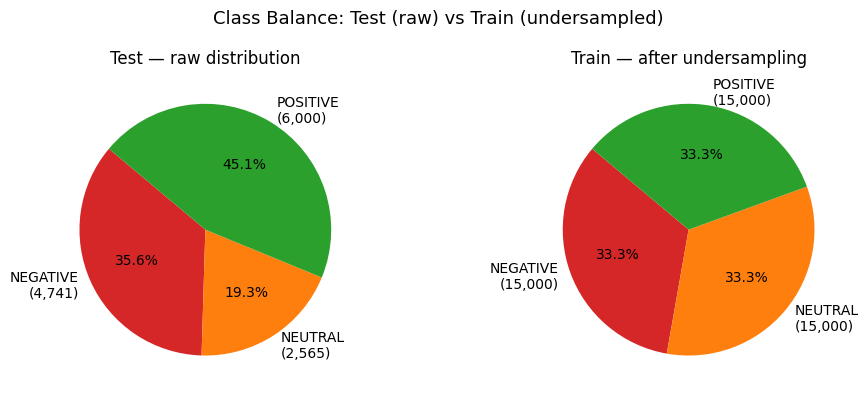

Saved fig03_balance_comparison.png


In [6]:
# Reconstruct pre-balance train proportions from val/test (same source distribution)
# Val and test are unbalanced, reflecting raw distribution
test_counts = test['label'].value_counts().sort_index()
train_counts = train['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Class Balance: Test (raw) vs Train (undersampled)', fontsize=13)

colors = ['#d62728', '#ff7f0e', '#2ca02c']
labels = [LABEL_NAMES[i] for i in [0, 1, 2]]

for ax, (title, counts) in zip(axes, [
    ('Test — raw distribution', test_counts),
    ('Train — after undersampling', train_counts)
]):
    ax.pie(
        counts.values,
        labels=[f'{LABEL_NAMES[i]}\n({counts[i]:,})' for i in counts.index],
        colors=colors,
        autopct='%1.1f%%',
        startangle=140
    )
    ax.set_title(title)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks' / 'fig03_balance_comparison.png', dpi=100)
plt.show()
print('Saved fig03_balance_comparison.png')

## 6. Category Distribution

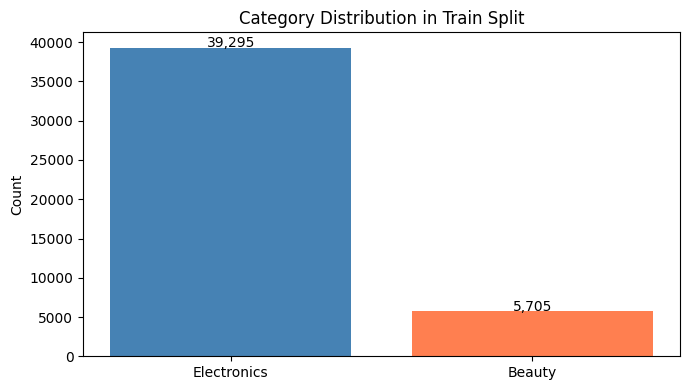

Saved fig04_category_distribution.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
cat_counts = train['category'].value_counts()
ax.bar(cat_counts.index, cat_counts.values, color=['steelblue', 'coral'])
ax.set_title('Category Distribution in Train Split')
ax.set_ylabel('Count')
for i, (cat, cnt) in enumerate(cat_counts.items()):
    ax.text(i, cnt + 100, f'{cnt:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks' / 'fig04_category_distribution.png', dpi=100)
plt.show()
print('Saved fig04_category_distribution.png')

## 7. Summary Statistics

In [8]:
with open(PROCESSED / 'dataset_stats.md', 'r', encoding='utf-8') as fh:
    print(fh.read())

# Dataset Statistics

Generated by `data/preprocess.py`. Reproducibility seed: 42.


## Split sizes

| Split | Rows |
|-------|------|
| train | 45,000 |
| val   | 13,306 |
| test  | 13,306 |
| **total** | 71,612 |

## Label distribution

| Split | NEGATIVE (0) | NEUTRAL (1) | POSITIVE (2) |
|-------|-------------|------------|-------------|
| train | 15,000 | 15,000 | 15,000 |
| val | 4,740 | 2,566 | 6,000 |
| test | 4,741 | 2,565 | 6,000 |

## Text length stats (characters)

| Split | Mean | Median | P95 |
|-------|------|--------|-----|
| train | 357.1 | 188.0 | 1230.0 |
| val | 334.9 | 178.0 | 1141.0 |
| test | 336.1 | 174.0 | 1166.8 |

## Category distribution (train)

| Category | Count |
|----------|-------|
| Electronics | 39,295 |
| Beauty | 5,705 |

